# Spectral sky recovery

Input vs recovered **flux** and **spectral-index ($\beta$)** maps for the model
$T(\theta,f) = \mathrm{flux}(\theta)\,(f/f_\mathrm{fid})^{\beta(\theta)}$,
fit by variable projection (`lusee.fitting`): flux is the *linear* block (Wiener solve),
$\beta$ the *non-linear* block (outer optimiser).

Run `python notebooks/spectral_fit_demo.py` first.  It writes
`spectral_fit_result_<truth>.npz` (`_ulsa` for real ULSA data, `_powerlaw` for
self-consistent data) — set `RESULT` in the next cell to choose which to view.

In [13]:
%matplotlib inline
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt


In [14]:
# Which fit to view: '_ulsa' (real ULSA data) or '_powerlaw' (self-consistent).
RESULT = 'spectral_fit_result_ulsa.npz'
d = np.load(RESULT)
lmax = int(d['lmax']); Nside = int(d['Nside'])
beta_nside = int(d['beta_nside']); f_fid = float(d['f_fid'])
flux_true = np.asarray(d['flux_true']).astype(complex)
flux_hat  = np.asarray(d['flux_hat']).astype(complex)
beta_true = np.asarray(d['beta_true']); beta_hat = np.asarray(d['beta_hat'])
rho = np.asarray(d['rho'])
print(f'{RESULT}:  lmax={lmax}  Nside={Nside}  beta_nside={beta_nside}  '
      f'freq={np.asarray(d["freq"]).tolist()} MHz  f_fid={f_fid} MHz')

spectral_fit_result_ulsa.npz:  lmax=15  Nside=8  beta_nside=4  freq=[15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0] MHz  f_fid=25.0 MHz


## Flux map: input vs recovered (linear block)

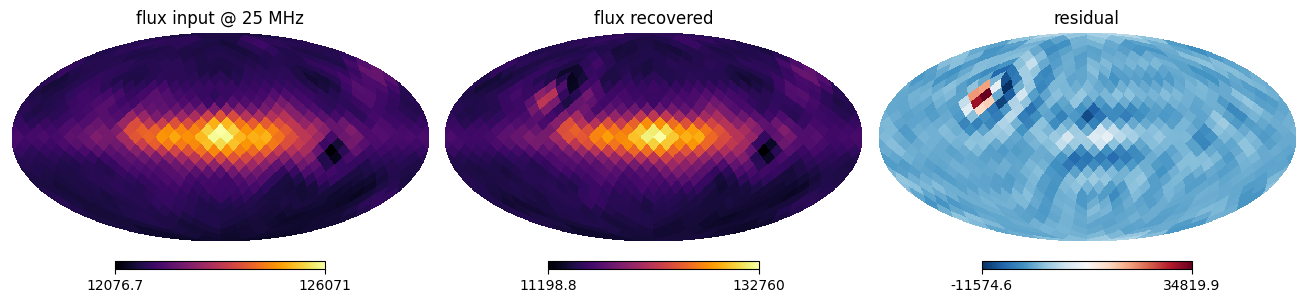

a00: true=134715  rec=135265


In [15]:
true_map = hp.alm2map(flux_true, Nside)
rec_map  = hp.alm2map(flux_hat,  Nside)
plt.figure(figsize=(13, 3.6))
hp.mollview(true_map, sub=(1, 3, 1), title=f'flux input @ {f_fid:.0f} MHz', cmap='inferno')
hp.mollview(rec_map,  sub=(1, 3, 2), title='flux recovered', cmap='inferno')
hp.mollview(rec_map - true_map, sub=(1, 3, 3), title='residual', cmap='RdBu_r')
plt.show()
print(f'a00: true={flux_true[0].real:.0f}  rec={flux_hat[0].real:.0f}')

## Spectral-index map $\beta$: input vs recovered (non-linear block)

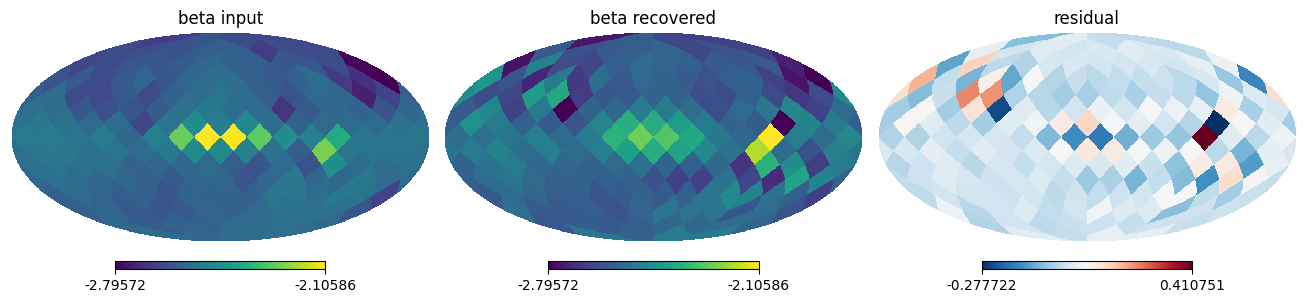

beta RMS(recovered - true) = 0.0713


In [16]:
vmin, vmax = float(beta_true.min()), float(beta_true.max())
plt.figure(figsize=(13, 3.6))
hp.mollview(beta_true, sub=(1, 3, 1), title='beta input', cmap='viridis', min=vmin, max=vmax)
hp.mollview(beta_hat,  sub=(1, 3, 2), title='beta recovered', cmap='viridis', min=vmin, max=vmax)
hp.mollview(beta_hat - beta_true, sub=(1, 3, 3), title='residual', cmap='RdBu_r')
plt.show()
print(f'beta RMS(recovered - true) = {np.sqrt(np.mean((beta_hat - beta_true)**2)):.4f}')

## Flux fidelity: $\rho_\ell$ and angular power spectrum

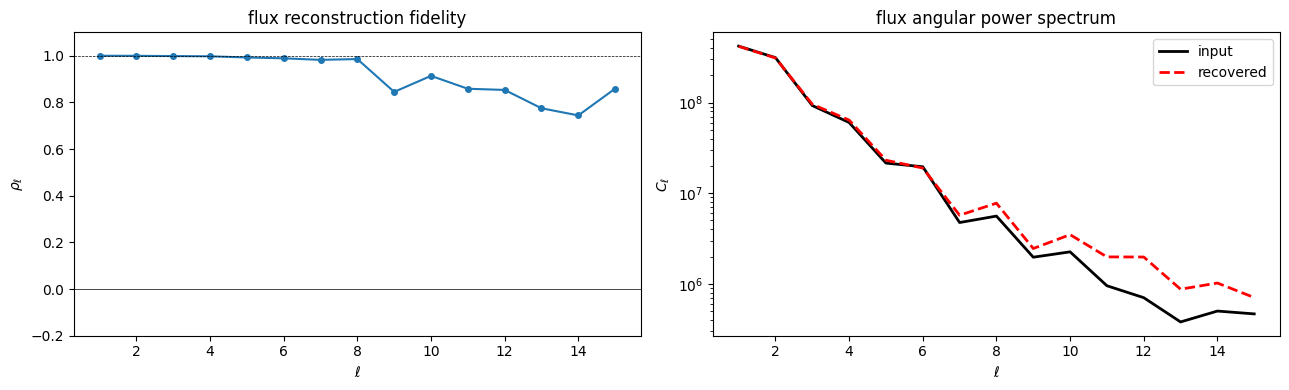

mean rho(1..10) = 0.9701


In [17]:
ell = np.arange(len(rho))
cl_true = hp.alm2cl(flux_true); cl_rec = hp.alm2cl(flux_hat)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(ell[1:lmax + 1], rho[1:lmax + 1], 'o-', ms=4)
a1.axhline(1, ls='--', c='k', lw=0.5); a1.axhline(0, c='k', lw=0.5)
a1.set_xlabel(r'$\ell$'); a1.set_ylabel(r'$\rho_\ell$')
a1.set_ylim(-0.2, 1.1); a1.set_title('flux reconstruction fidelity')
a2.semilogy(ell[1:lmax + 1], cl_true[1:lmax + 1], 'k-', lw=2, label='input')
a2.semilogy(ell[1:lmax + 1], cl_rec[1:lmax + 1], 'r--', lw=2, label='recovered')
a2.set_xlabel(r'$\ell$'); a2.set_ylabel(r'$C_\ell$')
a2.legend(); a2.set_title('flux angular power spectrum')
plt.tight_layout(); plt.show()
print(f'mean rho(1..{min(10, lmax)}) = {np.nanmean(rho[1:min(11, lmax + 1)]):.4f}')

## Optimiser convergence ($\chi^2$ vs evaluation)

Per-evaluation $\chi^2$ (including line-search trials) and the running minimum. At
the realistic SNR the $\chi^2$ floor is set by model mismatch, not noise; the
`converged` flag reports whether L-BFGS-B met its tolerance before `maxiter`.

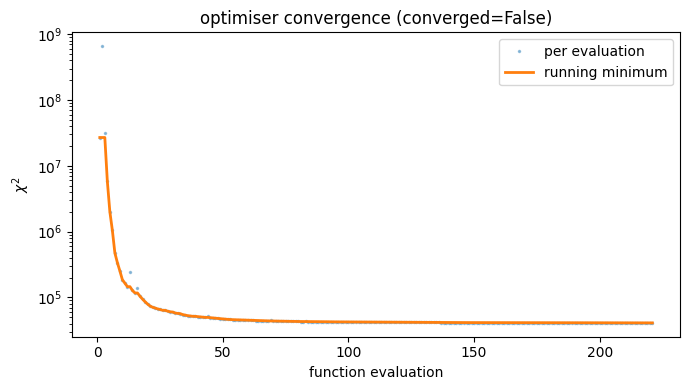

final chi2 = 4.0983e+04  over 221 evals  (converged=False)


In [18]:
if 'chi2_history' not in d.files:
    print('No chi2_history in this npz -- re-run the fit (driver now saves it).')
else:
    hist = np.asarray(d['chi2_history'])
    ev = np.arange(1, len(hist) + 1)
    runmin = np.minimum.accumulate(hist)
    conv = bool(d['converged']) if 'converged' in d.files else None
    plt.figure(figsize=(7, 4))
    plt.semilogy(ev, hist, '.', ms=3, alpha=0.4, label='per evaluation')
    plt.semilogy(ev, runmin, '-', lw=2, label='running minimum')
    plt.xlabel('function evaluation'); plt.ylabel(r'$\chi^2$')
    plt.title(f'optimiser convergence (converged={conv})')
    plt.legend(); plt.tight_layout(); plt.show()
    print(f'final chi2 = {hist[-1]:.4e}  over {len(hist)} evals  (converged={conv})')

## HMC posterior: estimate (mean) and per-mode SNR (std)

NUTS over the joint (flux, β) posterior (`lusee.fitting.sample_posterior`). The
posterior **mean** is a Bayesian-averaged estimate — it de-overfits the MAP — and
the per-pixel/per-mode **std** is the direct 1σ uncertainty, i.e. the SNR map.
The β **pull** = (mean − truth)/σ should be ~1σ where the model is correct.

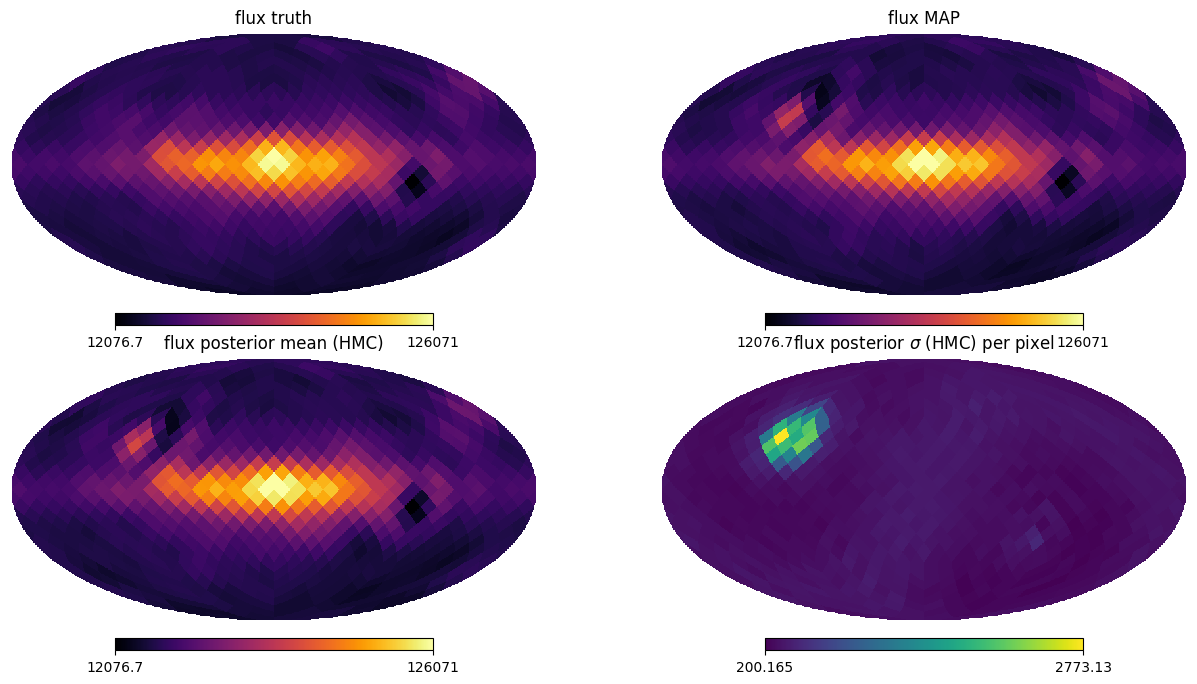

accept = 0.92;  median per-pixel flux SNR = 99


In [19]:
if 'flux_post_mean_map' not in d.files:
    print('No HMC products in this npz -- run the demo with sample=True.')
else:
    tru = np.asarray(d['flux_true_map']); mp = np.asarray(d['flux_map_map'])
    pm = np.asarray(d['flux_post_mean_map']); ps = np.asarray(d['flux_post_std_map'])
    vmin, vmax = float(tru.min()), float(tru.max())
    plt.figure(figsize=(13, 6.5))
    hp.mollview(tru, sub=(2, 2, 1), title='flux truth', cmap='inferno', min=vmin, max=vmax)
    hp.mollview(mp, sub=(2, 2, 2), title='flux MAP', cmap='inferno', min=vmin, max=vmax)
    hp.mollview(pm, sub=(2, 2, 3), title='flux posterior mean (HMC)', cmap='inferno', min=vmin, max=vmax)
    hp.mollview(ps, sub=(2, 2, 4), title=r'flux posterior $\sigma$ (HMC) per pixel', cmap='viridis')
    plt.show()
    print(f"accept = {float(d['accept']):.2f};  "
          f"median per-pixel flux SNR = {np.median(np.abs(pm)/np.maximum(ps,1e-9)):.0f}")

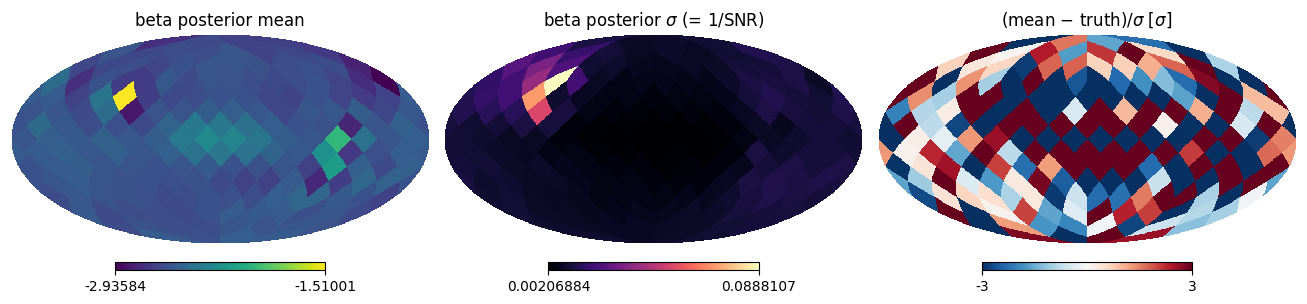

beta: median sigma = 0.009; median |pull| = 2.82 sigma (~1 if truth consistent with the posterior)


In [20]:
if 'beta_post_mean' not in d.files:
    print('No HMC beta products.')
else:
    bm = np.asarray(d['beta_post_mean']); bs = np.asarray(d['beta_post_std'])
    bt = np.asarray(d['beta_true'])
    pull = (bm - bt) / np.maximum(bs, 1e-9)
    plt.figure(figsize=(13, 3.4))
    hp.mollview(bm, sub=(1, 3, 1), title='beta posterior mean', cmap='viridis')
    hp.mollview(bs, sub=(1, 3, 2), title=r'beta posterior $\sigma$ (= 1/SNR)', cmap='magma')
    hp.mollview(pull, sub=(1, 3, 3), title=r'(mean $-$ truth)/$\sigma$ [$\sigma$]',
                cmap='RdBu_r', min=-3, max=3)
    plt.show()
    print(f'beta: median sigma = {np.median(bs):.3f}; '
          f'median |pull| = {np.median(np.abs(pull)):.2f} sigma '
          f'(~1 if truth consistent with the posterior)')

## SNR-weighted recovery (Wiener gain)

Each flux mode is weighted by its **Wiener gain** `w = S/(S+N)` — 1 for
signal-dominated modes, 0 for noise-dominated ones — so the comparison counts
only the modes the data could measure (without the high-SNR modes blowing up the
metric the way an unbounded `1/σ²` weight would). `rho_w` is the Wiener-weighted
correlation of recovered vs truth; `resid_frac` is the weighted residual power.
The whitened residual on the right is a diagnostic (≫1 std ⇒ systematics/model
mismatch dominate the well-measured modes).

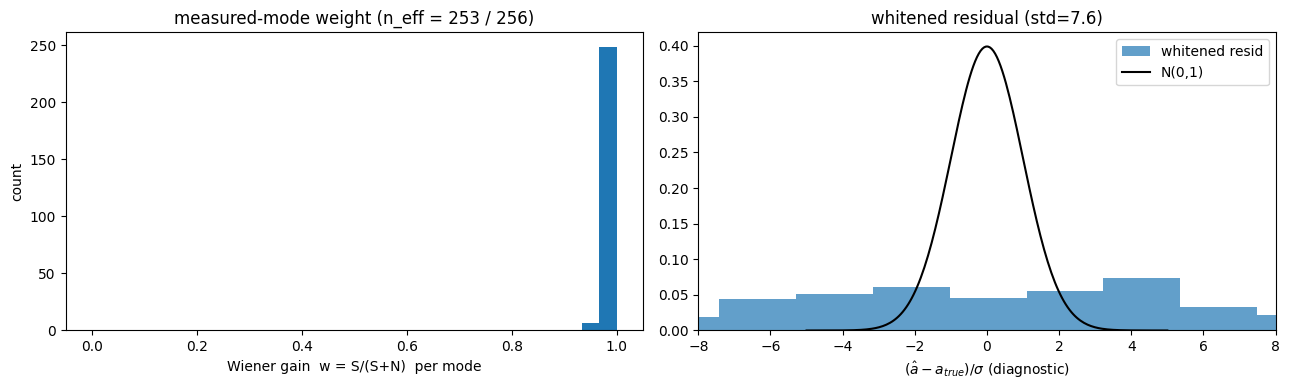

Wiener-weighted rho = 0.9986  (1 = recoverable modes recovered)
residual power fraction = 0.0029  (0 = perfect)
effective measured modes n_eff = 253.2 / 256


In [21]:
if 'wiener' not in d.files:
    print('No Fisher products -- run the demo with compute_fisher=True.')
else:
    w = np.asarray(d['wiener'])
    whit = np.asarray(d['whitened']); whit = whit[np.isfinite(whit)]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.hist(w, bins=30, range=(0, 1))
    a1.set_xlabel('Wiener gain  w = S/(S+N)  per mode'); a1.set_ylabel('count')
    a1.set_title(f'measured-mode weight (n_eff = {float(d["n_eff"]):.0f} / {len(w)})')
    a2.hist(whit, bins=40, density=True, alpha=0.7, label='whitened resid')
    xx = np.linspace(-5, 5, 200)
    a2.plot(xx, np.exp(-xx**2 / 2) / np.sqrt(2 * np.pi), 'k-', label='N(0,1)')
    a2.set_xlim(-8, 8); a2.legend()
    a2.set_xlabel(r'$(\hat a - a_{true})/\sigma$ (diagnostic)')
    a2.set_title(f'whitened residual (std={whit.std():.1f})')
    plt.tight_layout(); plt.show()
    print(f"Wiener-weighted rho = {float(d['rho_w']):.4f}  (1 = recoverable modes recovered)")
    print(f"residual power fraction = {float(d['resid_frac']):.4f}  (0 = perfect)")
    print(f"effective measured modes n_eff = {float(d['n_eff']):.1f} / {len(w)}")